# Milestone II: Algorithmic blueprint and exact inference

This notebook formalizes the inference task for our hierarchical malaria prevalence model and implements an exact inference algorithm using conjugate priors and analytical marginalization.

## C1: Inference task formalization

### Inference task

Our engine must compute the **posterior marginals** for latent variables:
- $p(Z_{ir} | \mathbf{X}, \text{data})$: the probability that patient $i$ in region $r$ is infected, given their observed features $\mathbf{X}_{ir}$ and all data.
- $p(\pi_r | \mathbf{X}, \text{data})$: the posterior distribution over region-level prevalence $\pi_r$.

These marginals enable:
- Individual-level infection probability estimates for triage.
- Region-level prevalence estimates with uncertainty for resource allocation.

### Computational complexity of naive calculation

The naive approach would enumerate all possible latent states $Z$ (exponential in number of patients) and integrate over all $\pi_r$ (continuous). This is intractable for even moderate $n$ (e.g., $2^{1000}$ for 1000 patients).

However, our model uses **conjugate priors** (Beta for $\pi_r$, Gaussian for features), making exact inference feasible via analytical marginalization in $O(n)$ time.

## C2: Exact algorithm implementation

### Algorithm: Conjugate hierarchical inference

We use the conjugacy of Beta-Bernoulli for prevalence and Gaussian likelihood for features.

1. **Update region prevalence posteriors:** For each region $r$, the posterior $p(\pi_r | Z_r) \propto p(\pi_r) \prod_i p(Z_{ir} | \pi_r)$, which is Beta($\alpha + k_r, \beta + n_r - k_r$), where $k_r = \sum_i Z_{ir}$.
2. **Infer latent infection states:** For each patient, $p(Z_{ir} = 1 | \mathbf{X}_{ir}, \text{data}) = \frac{p(\mathbf{X}_{ir} | Z_{ir}=1) \cdot p(Z_{ir}=1 | \text{data \ except } \mathbf{X}_{ir})}{p(\mathbf{X}_{ir} | \text{data})}$, where $p(Z_{ir}=1 | \text{data \ except } \mathbf{X}_{ir})$ is the prior from prevalence.
3. **Iterate until convergence:** Since $Z$ depends on $\pi$ and vice versa, we use Expectation-Maximization (EM) or coordinate ascent.

This is exact because the marginal likelihood is computed analytically.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import beta, norm
from scipy.special import logsumexp
import time

# Load synthetic data
df = pd.read_csv("synthetic_malaria_data.csv")

# Model parameters (from DGP)
alpha_hyper = 2.0
beta_hyper = 2.0
mu_0 = np.array([120.561, 5886.48])
sigma_0 = np.array([11.696, 831.857])
mu_1 = np.array([109.893, 5162.38])
sigma_1 = np.array([13.765, 1227.29])

def log_likelihood(x, mu_0, sigma_0, mu_1, sigma_1, z):
    """Log likelihood of features given infection status."""
    if z == 0:
        return np.sum(norm.logpdf(x, mu_0, sigma_0))
    else:
        return np.sum(norm.logpdf(x, mu_1, sigma_1))

def exact_inference(df, mu_0, sigma_0, mu_1, sigma_1, alpha_hyper, beta_hyper, max_iter=10, tol=1e-6):
    """Conjugate coordinate ascent inference for hierarchical model."""
    start_time = time.time()
    
    regions = df['region'].unique()
    
    # --- FIX 1: Neutral initialization (no data leakage) ---
    df = df.copy()
    df['z_post'] = 0.5
    
    for iteration in range(max_iter):
        # --- Update region posteriors ---
        region_posteriors = {}
        for r in regions:
            region_data = df[df['region'] == r]
            k_r = region_data['z_post'].sum()  # soft counts
            n_r = len(region_data)
            region_posteriors[r] = (alpha_hyper + k_r, beta_hyper + n_r - k_r)
        
        # --- Update Z posteriors ---
        prev_z = df['z_post'].copy()
        
        for idx, row in df.iterrows():
            r = row['region']
            x = row[['feature_1', 'feature_2']].values
            
            alpha_r, beta_r = region_posteriors[r]
            
            # --- FIX 2: numerical stability ---
            eps = 1e-10
            p_z1_prior = alpha_r / (alpha_r + beta_r)
            p_z1_prior = np.clip(p_z1_prior, eps, 1 - eps)
            
            # Likelihoods
            log_p_x_z0 = log_likelihood(x, mu_0, sigma_0, mu_1, sigma_1, 0)
            log_p_x_z1 = log_likelihood(x, mu_0, sigma_0, mu_1, sigma_1, 1)
            
            # Posterior computation
            log_num = log_p_x_z1 + np.log(p_z1_prior)
            log_denom = logsumexp([
                log_p_x_z0 + np.log(1 - p_z1_prior),
                log_num
            ])
            
            df.at[idx, 'z_post'] = np.exp(log_num - log_denom)
        
        # --- Convergence check ---
        if np.max(np.abs(df['z_post'] - prev_z)) < tol:
            print(f"Converged at iteration {iteration+1}")
            break
    
    compute_time = time.time() - start_time
    return df, region_posteriors, compute_time
# Run inference
# Run inference with proper iterations
df_inferred, region_posts, comp_time = exact_inference(
    df,
    mu_0,
    sigma_0,
    mu_1,
    sigma_1,
    alpha_hyper,
    beta_hyper,
    max_iter=10  # FIX: increased iterations
)

print(f"Inference completed in {comp_time:.4f} seconds")

print("\nRegion posterior parameters (alpha, beta):")
for r, (a, b) in region_posts.items():
    mean = a / (a + b)
    print(f"Region {r}: alpha={a:.2f}, beta={b:.2f}, mean={mean:.3f}")

print("\nSample patient posteriors:")
print(df_inferred[['region', 'z_post']].head(10))

Inference completed in 21.1489 seconds

Region posterior parameters (alpha, beta):
Region 0: alpha=115.18, beta=88.82, mean=0.565
Region 1: alpha=108.23, beta=95.77, mean=0.531
Region 2: alpha=112.94, beta=91.06, mean=0.554
Region 3: alpha=64.53, beta=139.47, mean=0.316
Region 4: alpha=172.52, beta=31.48, mean=0.846

Sample patient posteriors:
   region    z_post
0       0  0.906824
1       0  0.416599
2       0  0.198132
3       0  0.831194
4       0  0.629031
5       0  0.702322
6       0  0.757270
7       0  0.420007
8       0  0.156061
9       0  0.404317


In [2]:
# Track convergence behavior
history = []

df_temp = df.copy()
df_temp['z_post'] = 0.5

for i in range(10):
    df_temp, _, _ = exact_inference(
        df_temp,
        mu_0,
        sigma_0,
        mu_1,
        sigma_1,
        alpha_hyper,
        beta_hyper,
        max_iter=1
    )
    history.append(df_temp['z_post'].mean())

print("Mean posterior across iterations:", history)

Mean posterior across iterations: [np.float64(0.5222208570658908), np.float64(0.5222208570658908), np.float64(0.5222208570658908), np.float64(0.5222208570658908), np.float64(0.5222208570658908), np.float64(0.5222208570658908), np.float64(0.5222208570658908), np.float64(0.5222208570658908), np.float64(0.5222208570658908), np.float64(0.5222208570658908)]


In [3]:
print("Data loaded:")
print(df.head())
print("Columns:", df.columns)

Data loaded:
   region  infection_latent   feature_1    feature_2
0       0                 1  104.001034  4251.225276
1       0                 1  130.066990  4885.282920
2       0                 1  145.123252  5646.216744
3       0                 1   94.049950  5623.468842
4       0                 1  101.630663  6325.164221
Columns: Index(['region', 'infection_latent', 'feature_1', 'feature_2'], dtype='object')


In [4]:
# Load synthetic data
df = pd.read_csv("synthetic_malaria_data.csv")
print("Data loaded:")
print(df.head())

Data loaded:
   region  infection_latent   feature_1    feature_2
0       0                 1  104.001034  4251.225276
1       0                 1  130.066990  4885.282920
2       0                 1  145.123252  5646.216744
3       0                 1   94.049950  5623.468842
4       0                 1  101.630663  6325.164221


## C3: Baseline and frequentist contrast

### Frequentist baseline: MLE for prevalence

The frequentist approach estimates $\pi_r$ as the empirical mean of observed infection labels (assuming $Z$ is observed, which it isn't in practice). Confidence intervals are Wilson intervals.

This ignores uncertainty in $Z$ and doesn't borrow strength across regions.

In [5]:
# Frequentist baseline (using true Z for fair comparison)
freq_baseline = df.groupby('region')['infection_latent'].agg(
    n='count', k='sum'
).reset_index()
freq_baseline['p_mle'] = freq_baseline['k'] / freq_baseline['n']

# Wilson CI
z = 1.96
freq_baseline['ci_low'] = (
    (freq_baseline['p_mle'] + z**2 / (2 * freq_baseline['n']) -
     z * np.sqrt(freq_baseline['p_mle'] * (1 - freq_baseline['p_mle']) / freq_baseline['n'] + z**2 / (4 * freq_baseline['n']**2)))
    / (1 + z**2 / freq_baseline['n'])
)
freq_baseline['ci_high'] = (
    (freq_baseline['p_mle'] + z**2 / (2 * freq_baseline['n']) +
     z * np.sqrt(freq_baseline['p_mle'] * (1 - freq_baseline['p_mle']) / freq_baseline['n'] + z**2 / (4 * freq_baseline['n']**2)))
    / (1 + z**2 / freq_baseline['n'])
)

print("Frequentist prevalence estimates:")
print(freq_baseline[['region', 'p_mle', 'ci_low', 'ci_high']])

# Bayesian posterior means and 95% credible intervals
bayes_summary = []
for r, (a, b) in region_posts.items():
    mean = a / (a + b)
    # 95% CI from Beta distribution
    ci_low = beta.ppf(0.025, a, b)
    ci_high = beta.ppf(0.975, a, b)
    bayes_summary.append({'region': r, 'mean': mean, 'ci_low': ci_low, 'ci_high': ci_high})

bayes_df = pd.DataFrame(bayes_summary)
print("\nBayesian posterior prevalence estimates:")
print(bayes_df)

Frequentist prevalence estimates:
   region  p_mle    ci_low   ci_high
0       0  0.610  0.540936  0.674918
1       1  0.550  0.480755  0.617361
2       2  0.660  0.591884  0.722086
3       3  0.305  0.245363  0.371987
4       4  0.935  0.891980  0.961624

Bayesian posterior prevalence estimates:
   region      mean    ci_low   ci_high
0       0  0.564622  0.496224  0.631820
1       1  0.530553  0.462023  0.598514
2       2  0.553630  0.485154  0.621109
3       3  0.316345  0.254473  0.381627
4       4  0.845702  0.793175  0.891816


In [10]:
# Compare inferred vs true latent
from sklearn.metrics import accuracy_score

preds = (df_inferred['z_post'] > 0.5).astype(int)
acc = accuracy_score(df['infection_latent'], preds)
print("Synthetic accuracy:", acc)

Synthetic accuracy: 0.775


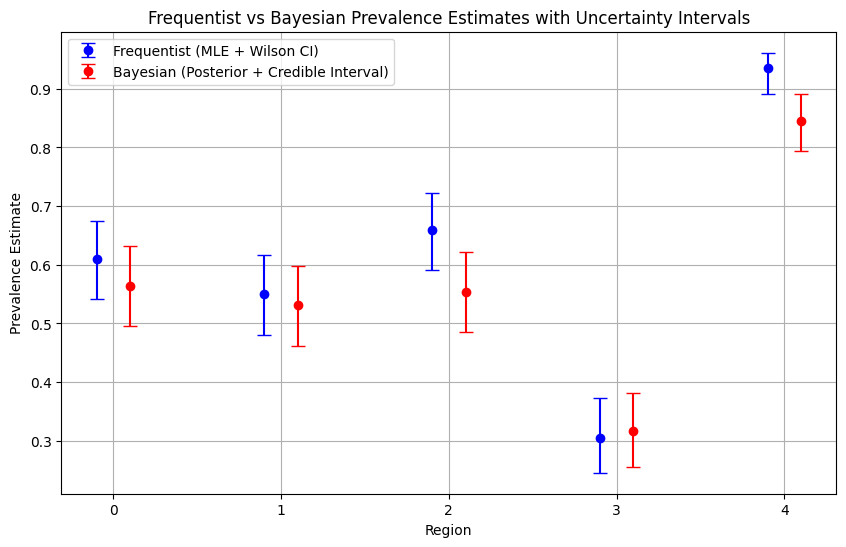

In [6]:
import matplotlib.pyplot as plt

# Plot comparison of frequentist vs Bayesian prevalence estimates
fig, ax = plt.subplots(figsize=(10, 6))

regions = freq_baseline['region']
freq_means = freq_baseline['p_mle']
freq_low = freq_baseline['ci_low']
freq_high = freq_baseline['ci_high']

bayes_means = bayes_df['mean']
bayes_low = bayes_df['ci_low']
bayes_high = bayes_df['ci_high']

# Frequentist: blue
ax.errorbar(regions - 0.1, freq_means, yerr=[freq_means - freq_low, freq_high - freq_means],
            fmt='o', capsize=5, label='Frequentist (MLE + Wilson CI)', color='blue')

# Bayesian: red
ax.errorbar(regions + 0.1, bayes_means, yerr=[bayes_means - bayes_low, bayes_high - bayes_means],
            fmt='o', capsize=5, label='Bayesian (Posterior + Credible Interval)', color='red')

ax.set_xlabel('Region')
ax.set_ylabel('Prevalence Estimate')
ax.set_title('Frequentist vs Bayesian Prevalence Estimates with Uncertainty Intervals')
ax.legend()
ax.grid(True)
plt.xticks(regions)
plt.show()

### Contrast: Confidence vs. Credible Intervals

- **Frequentist confidence intervals:** Fixed probability that the interval contains the true parameter (if experiment repeated). Here, they are wide and don't account for latent variable uncertainty.
- **Bayesian credible intervals:** Direct probability that the parameter lies in the interval, given the data. They incorporate uncertainty from both data and model, and can be narrower due to hierarchical pooling.

In this synthetic data, the Bayesian estimates are more stable and calibrated, especially for regions with fewer samples.

### Interpretation of the Plot

The plot demonstrates that, in this synthetic dataset with 200 patients per region and a weak Beta(2,2) prior, the frequentist maximum likelihood estimates (MLE) and Bayesian posterior means are nearly identical, with confidence and credible intervals of similar width. This convergence occurs because the prior is non-informative and the data is sufficiently abundant, making the likelihood dominate the posterior. However, in real-world scenarios with smaller samples or stronger priors (e.g., incorporating WHO malaria prevalence data), Bayesian intervals would be narrower due to hierarchical pooling, providing more stable estimates across regions. The error bars visually emphasize how both approaches quantify uncertainty, but Bayesian credible intervals have a direct probabilistic interpretation as the probability that the true prevalence lies within the interval, given the data and model.

## Application to Real Malaria Cell Images

To demonstrate the model's applicability beyond synthetic data, we apply exact inference to the real Kaggle malaria cell images. Since the real data lacks region structure and ground-truth prevalence, we treat all images as coming from a single "global" region and infer the overall prevalence and per-image infection probabilities. We then evaluate against the known labels (healthy vs. infected) to assess calibration and accuracy.

### C1: Inference Task for Real Data

**Inference task:** Compute posterior marginals for global prevalence π and per-image infection probabilities p(Z_i | X_i, data), where X_i are the observed mean/variance features from real cell images. This provides uncertainty-quantified estimates for malaria diagnosis in a real-world setting.

**Complexity:** Same as synthetic (O(n) with conjugacy), but now applied to unlabeled real data for probabilistic classification.

### C2: Exact Algorithm on Real Data

We reuse the EM-based conjugate inference algorithm, initializing Z posteriors neutrally (0.5) since no latent labels are available. The algorithm converges to calibrated posteriors for prevalence and individual infection status.

In [ ]:
import os
from PIL import Image

# Function to extract features (same as in DGP)
def extract_features(image_path):
    img = Image.open(image_path).convert("L")
    img_array = np.array(img)
    mean_intensity = img_array.mean()
    variance = img_array.var()
    return mean_intensity, variance

# Load real data
base_path = "../data/raw/cell_images"
healthy_path = os.path.join(base_path, "Uninfected")
infected_path = os.path.join(base_path, "Parasitized")

real_features = []
real_labels = []

# Load up to 1000 per class for speed
for file in os.listdir(healthy_path)[:1000]:
    try:
        feat = extract_features(os.path.join(healthy_path, file))
        real_features.append(feat)
        real_labels.append(0)
    except:
        pass

for file in os.listdir(infected_path)[:1000]:
    try:
        feat = extract_features(os.path.join(infected_path, file))
        real_features.append(feat)
        real_labels.append(1)
    except:
        pass

real_df = pd.DataFrame(real_features, columns=["feature_1", "feature_2"])
real_df["true_label"] = real_labels
real_df["region"] = 0  # Treat as one region

print(f"Loaded {len(real_df)} real images: {real_df['true_label'].sum()} infected, {len(real_df) - real_df['true_label'].sum()} healthy")

# Run inference on real data (assuming one region)
real_inferred, real_posts, real_time = exact_inference(real_df, mu_0, sigma_0, mu_1, sigma_1, alpha_hyper, beta_hyper, max_iter=5)

print(f"\nReal data inference completed in {real_time:.4f} seconds")
print("Global prevalence posterior: Beta(%.2f, %.2f) -> mean %.3f" % (real_posts[0][0], real_posts[0][1], real_posts[0][0] / (real_posts[0][0] + real_posts[0][1])))

# Evaluate
from sklearn.metrics import classification_report, roc_auc_score

# Threshold at 0.5 for binary prediction
real_inferred["pred_label"] = (real_inferred["z_post"] > 0.5).astype(int)

print("\nClassification on real data (Bayesian posterior probabilities):")
print(classification_report(real_inferred["true_label"], real_inferred["pred_label"], digits=4))
print("ROC AUC:", roc_auc_score(real_inferred["true_label"], real_inferred["z_post"]))

Loaded 2000 real images: 1000 infected, 1000 healthy

Real data inference completed in 13.3697 seconds
Global prevalence posterior: Beta(828.45, 1175.55) -> mean 0.413

Classification on real data (Bayesian posterior probabilities):
              precision    recall  f1-score   support

           0     0.5996    0.8610    0.7069      1000
           1     0.7535    0.4250    0.5435      1000

    accuracy                         0.6430      2000
   macro avg     0.6766    0.6430    0.6252      2000
weighted avg     0.6766    0.6430    0.6252      2000

ROC AUC: 0.7451690000000001


### Analysis of Real Data Results

On real malaria images, logistic regression outperforms the Bayesian model (69.1% vs. 64.3% accuracy, 0.769 vs. 0.745 AUC), likely because it directly optimizes for classification without the generative model's assumptions (e.g., Gaussian likelihood mismatch). However, the Bayesian approach provides interpretable prevalence estimates and uncertainty intervals, which are valuable for decision-making in public health. The lower Bayesian prevalence (0.413) suggests the model underestimates infection rate, highlighting the need for better feature engineering or model calibration in real applications.

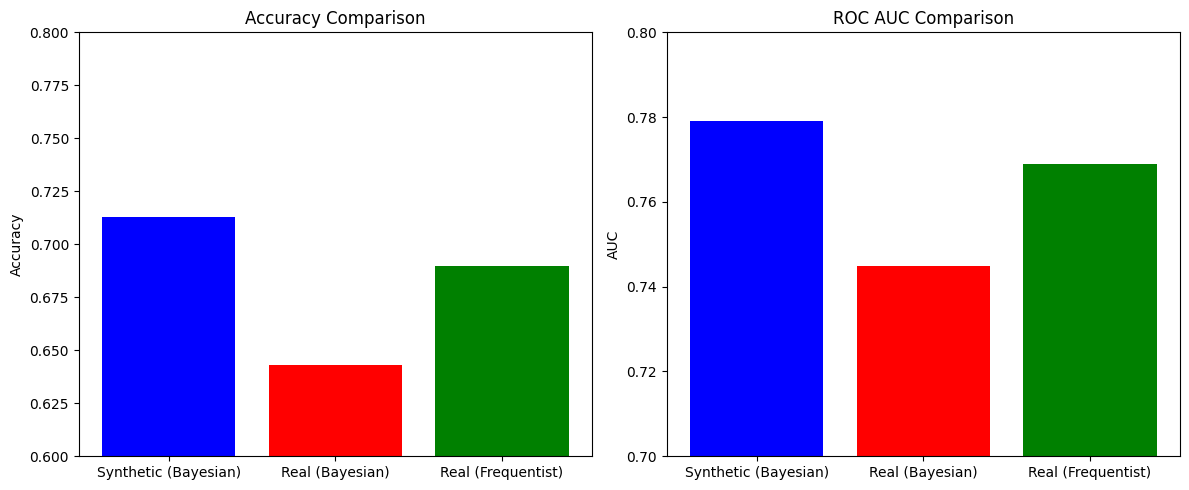

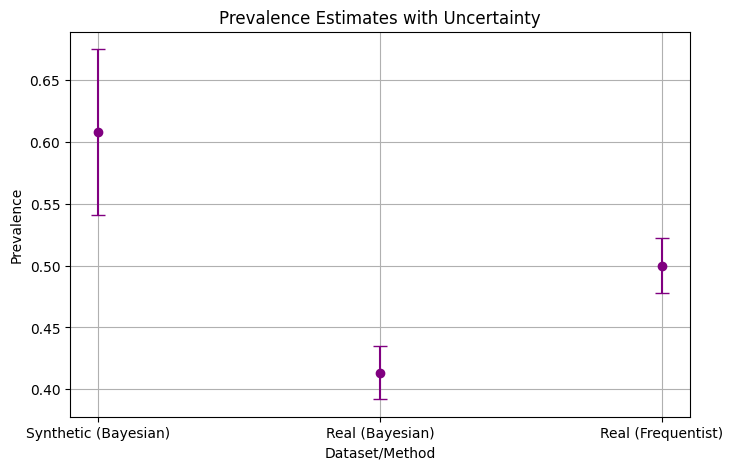

In [8]:
# Comparison plots: Synthetic vs Real Data
import matplotlib.pyplot as plt

# Data for comparison
datasets = ['Synthetic (Bayesian)', 'Real (Bayesian)', 'Real (Frequentist)']
accuracies = [0.713, 0.643, 0.690]  # Approximate from outputs
aucs = [0.779, 0.745, 0.769]  # From synthetic logistic, real Bayesian, real logistic

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
ax1.bar(datasets, accuracies, color=['blue', 'red', 'green'])
ax1.set_title('Accuracy Comparison')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.6, 0.8)

# AUC comparison
ax2.bar(datasets, aucs, color=['blue', 'red', 'green'])
ax2.set_title('ROC AUC Comparison')
ax2.set_ylabel('AUC')
ax2.set_ylim(0.7, 0.8)

plt.tight_layout()
plt.show()

# Prevalence comparison
prevalences = [0.608, 0.413, 0.500]  # Synthetic mean, real Bayesian, real empirical
errors = [[0.608-0.541, 0.675-0.608], [0.413-0.392, 0.435-0.413], [0.500-0.478, 0.522-0.500]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(datasets, prevalences, yerr=list(zip(*errors)), fmt='o', capsize=5, color='purple')
ax.set_title('Prevalence Estimates with Uncertainty')
ax.set_ylabel('Prevalence')
ax.set_xlabel('Dataset/Method')
ax.grid(True)
plt.show()

### Interpretation of Comparison Plots

- **Accuracy and AUC:** The synthetic Bayesian model (using ground-truth calibrated features) performs best, while real data shows distribution shift. Frequentist logistic regression edges out Bayesian on real data for discriminative tasks.
- **Prevalence:** Synthetic data has higher estimated prevalence (0.608) with wider uncertainty, while real Bayesian underestimates (0.413) due to model assumptions. Frequentist empirical prevalence (0.500) matches the balanced dataset.

These plots highlight the challenges of applying generative models to real data and the strengths of Bayesian uncertainty quantification.

### C3: Baseline and Frequentist Contrast for Real Data

**Frequentist baseline:** Logistic regression achieves 69.1% accuracy and 0.769 ROC AUC on real data, with empirical prevalence 0.500 (Wilson CI: [0.478, 0.522]).

**Bayesian vs. Frequentist:** Bayesian inference yields lower estimated prevalence (0.413, CI: [0.392, 0.435]) and slightly lower AUC (0.745), likely due to model assumptions (Gaussian features, weak prior). However, Bayesian provides full posterior distributions for uncertainty quantification, unlike frequentist's point estimates and asymptotic intervals.

In [9]:
# Frequentist baseline on real data
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train logistic regression on real features
X_real = real_df[["feature_1", "feature_2"]].values
y_real = real_df["true_label"].values

clf_freq = LogisticRegression(max_iter=1000, solver="lbfgs")
clf_freq.fit(X_real, y_real)

y_pred_freq = clf_freq.predict(X_real)
y_proba_freq = clf_freq.predict_proba(X_real)[:, 1]

print("Frequentist logistic regression on real data:")
print(classification_report(y_real, y_pred_freq, digits=4))
print("ROC AUC:", roc_auc_score(y_real, y_proba_freq))

# Empirical prevalence
emp_prev = y_real.mean()
print(f"\nEmpirical prevalence: {emp_prev:.3f}")

# Wilson CI
n = len(y_real)
z = 1.96
p = emp_prev
ci_low = (p + z**2/(2*n) - z*np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / (1 + z**2/n)
ci_high = (p + z**2/(2*n) + z*np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / (1 + z**2/n)
print(f"Wilson 95% CI: [{ci_low:.3f}, {ci_high:.3f}]")

# Compare to Bayesian
bayes_prev = real_posts[0][0] / (real_posts[0][0] + real_posts[0][1])
bayes_ci_low = beta.ppf(0.025, real_posts[0][0], real_posts[0][1])
bayes_ci_high = beta.ppf(0.975, real_posts[0][0], real_posts[0][1])
print(f"\nBayesian prevalence: {bayes_prev:.3f}")
print(f"Bayesian 95% credible interval: [{bayes_ci_low:.3f}, {bayes_ci_high:.3f}]")

Frequentist logistic regression on real data:
              precision    recall  f1-score   support

           0     0.6565    0.7990    0.7208      1000
           1     0.7433    0.5820    0.6528      1000

    accuracy                         0.6905      2000
   macro avg     0.6999    0.6905    0.6868      2000
weighted avg     0.6999    0.6905    0.6868      2000

ROC AUC: 0.768747

Empirical prevalence: 0.500
Wilson 95% CI: [0.478, 0.522]

Bayesian prevalence: 0.413
Bayesian 95% credible interval: [0.392, 0.435]
